# Task 1 · Preattentive attributes and visual search

**Ali Afzal** · BSAI-7B-102 · Data Visualization · Week 2

A red circle among blue ones jumps out. A square among circles jumps out. But a red circle hidden among red
squares and blue circles has to be hunted for. This notebook measures that difference on a real person.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# Paul Tol "bright" palette: stays distinct for colour-blind readers
RED, BLUE, GREY, INK = "#ee6677", "#4477aa", "#bbbbbb", "#333333"

plt.rcParams.update({
    "figure.dpi": 100,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlelocation": "left",
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
})


def save(fig, name):
    fig.savefig(CHARTS / name, dpi=300, bbox_inches="tight")

In [2]:
stim = pd.read_csv(DATA / "stimuli_search.csv")
trials = stim.drop_duplicates("trial")[["trial", "condition", "set_size", "target_present"]]

print(f"{len(stim):,} items across {len(trials)} trials")
trials.pivot_table(index="condition", columns="set_size", values="trial", aggfunc="count")

2,430 items across 90 trials


set_size,9,16,25,36,49
condition,,,,,
colour,6,6,6,6,6
conjunction,6,6,6,6,6
shape,6,6,6,6,6


Six trials per cell: target present or absent, three repeats each.

## 1. The three searches

In [3]:
COLOURS = {"red": RED, "blue": BLUE}
MARKERS = {"circle": "o", "square": "s"}


def draw_trial(trial, ax):
    items = stim[stim.trial == trial]
    shift = (7 - np.sqrt(len(items))) / 2   # centre the grid in a fixed 7 x 7 frame
    for (colour, shape), group in items.groupby(["colour", "shape"]):
        ax.scatter(group.x + shift, group.y + shift, s=120, color=COLOURS[colour],
                   marker=MARKERS[shape], linewidths=0)
    ax.set_xlim(0, 7)
    ax.set_ylim(0, 7)
    ax.set_aspect("equal")
    ax.axis("off")

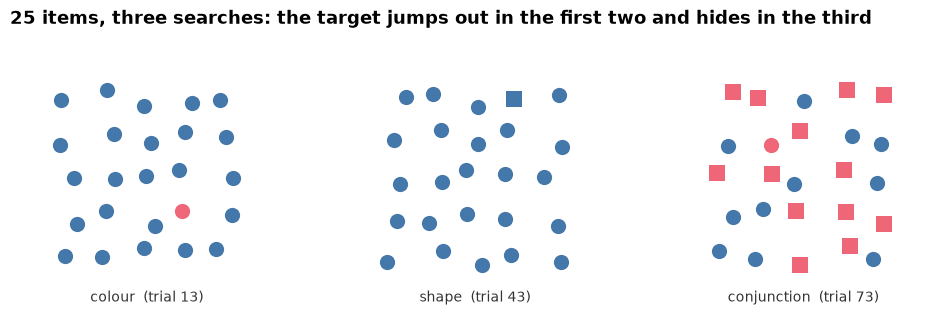

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
for ax, cond in zip(axes, ["colour", "shape", "conjunction"]):
    trial = trials.query("condition == @cond and set_size == 25 and target_present == 'yes'").trial.iloc[0]
    draw_trial(trial, ax)
    ax.text(3.5, 0.6, f"{cond}  (trial {trial})", ha="center", va="top", color=INK)

# title on the first axes so it hugs the squares; it runs on across the other two
axes[0].set_title("25 items, three searches: the target jumps out in the first two and hides in the third",
                  fontsize=13, pad=12)
save(fig, "t1_trials_set25.png")

**What the eye does**

- **Colour.** The red circle is the only red item. Hue is preattentive, so you see it before you start looking.
- **Shape.** The square is the only item with corners. Shape is preattentive too, but it stands out a bit
  less than colour does.
- **Conjunction.** Half the distractors are red and the other half are circles, so the target isn't the only
  one of anything. Nothing pops out, and you have to scan.

Attributes used: **hue** (colour) and **shape** (form). Both suit categorical data, and "target vs
distractor" is categorical.

Adding items doesn't make the display more crowded. The spacing stays the same and the items cover more of
the screen. So a bigger set means more to scan, not tighter packing.

## 2. The experiment

The reader was asked one question on every trial: **"Is the target there, yes or no?"** The target was named
before each block and never during one. The order of the blocks and of the trials was shuffled.

There were **18 trials**: 3 conditions × 3 set sizes (9, 25 and 49) × target present or absent. The brief's
"two per cell" with all five set sizes would make 30, so I kept 18 and spread them across the full range.

Response time runs from the moment the display appears to the answer, so it includes typing `y` or `n`.
That adds about the same delay to every trial. It raises every line but doesn't change any slope.

In [5]:
PICK_SIZES = [9, 25, 49]

picked = (
    trials[trials.set_size.isin(PICK_SIZES)]
    .groupby(["condition", "set_size", "target_present"])
    .sample(1, random_state=7)
    .reset_index(drop=True)
)
picked

,trial,condition,set_size,target_present
0,6,colour,9,no
1,1,colour,9,yes
2,18,colour,25,no
3,13,colour,25,yes
4,30,colour,49,no
5,26,colour,49,yes
6,65,conjunction,9,no
7,62,conjunction,9,yes
8,78,conjunction,25,no
9,74,conjunction,25,yes


In [6]:
import time

from IPython.display import clear_output, display

RESULTS = Path("search_results.csv")
# To run: set READER, flip RUN_EXPERIMENT to True and run this cell with the reader.
# Then flip it back to False and Restart & Run All.
RUN_EXPERIMENT = False
READER = "a classmate"

TARGET = {
    "colour": "the RED circle (everything else is a blue circle)",
    "shape": "the SQUARE (everything else is a circle)",
    "conjunction": "the RED CIRCLE (others are red squares and blue circles)",
}


def run_search(picked, reader):
    rng = np.random.default_rng()
    rows = []
    for cond in rng.permutation(picked.condition.unique()):
        clear_output()
        input(f"Next block: find {TARGET[cond]}. Press Enter when ready.")
        block = picked[picked.condition == cond]
        for _, t in block.iloc[rng.permutation(len(block))].iterrows():
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(5, 5))
            draw_trial(t.trial, ax)
            display(fig)
            plt.close(fig)

            start = time.perf_counter()
            answer = input("Is the target there? y / n: ").strip().lower()[:1]
            rt_ms = (time.perf_counter() - start) * 1000

            rows.append({
                **t.to_dict(),
                "response": answer,
                "correct": (answer == "y") == (t.target_present == "yes"),
                "rt_ms": round(rt_ms),
                "reader": reader,
            })
    clear_output()
    return pd.DataFrame(rows)


if RUN_EXPERIMENT:
    run_search(picked, READER).to_csv(RESULTS, index=False)

if RESULTS.exists():
    results = pd.read_csv(RESULTS)
    display(results)
else:
    results = None
    print("No search_results.csv yet. Set RUN_EXPERIMENT = True and run this cell with your reader.")

No search_results.csv yet. Set RUN_EXPERIMENT = True and run this cell with your reader.


## 3. Response time vs set size

This chart uses target-present trials only. "No" answers are slower in every condition, because the
reader has to check the whole display before giving up. Mixing them in would blur the slopes.

In [7]:
FLAT = 10  # ms per item. Below this I call a slope flat.


def headline(slope):
    rising = [c for c, s in slope.items() if s > FLAT]
    if rising == ["conjunction"]:
        return f"Only the conjunction search slowed as the display grew (+{slope['conjunction']:.0f} ms per item)"
    if not rising:
        return "No search slowed as the display grew, not even the conjunction"
    return f"Search slowed as the display grew for: {', '.join(rising)}"


def spread(ys, gap):
    """Nudge label heights apart so no two sit closer than `gap`."""
    ys = np.asarray(ys, dtype=float)
    out = ys.copy()
    order = np.argsort(ys)
    for lo, hi in zip(order, order[1:]):
        out[hi] = max(out[hi], out[lo] + gap)
    return out


if results is None:
    print("Waiting for search_results.csv. Run step 2 first.")
else:
    present = results[results.target_present == "yes"]
    rt = present.pivot_table(index="set_size", columns="condition", values="rt_ms")
    slope = {c: np.polyfit(rt.index, rt[c], 1)[0] for c in rt.columns}

    look = {
        "colour": dict(color=GREY, ls="--", marker="o"),
        "shape": dict(color=GREY, ls=":", marker="s"),
        "conjunction": dict(color=RED, lw=2.5, marker="o"),
    }
    fig, ax = plt.subplots(figsize=(8, 5))
    for cond, kw in look.items():
        ax.plot(rt.index, rt[cond], **kw)

    span = np.ptp(rt.values) or 1
    ends = spread([rt[c].iloc[-1] for c in look], gap=0.06 * span)
    for cond, y in zip(look, ends):
        ax.annotate(f"{cond}  {round(slope[cond]):+d} ms/item", (rt.index[-1], y), xytext=(10, 0),
                    textcoords="offset points", va="center",
                    color=RED if cond == "conjunction" else "#777777")

    ax.set_xticks(rt.index)
    ax.set_xlabel("Items on screen")
    ax.set_ylabel("Response time (ms)")
    ax.set_title(headline(slope))
    wrong = (~present.correct).sum()
    ax.annotate(f"One reader ({READER}). Target-present trials only, n = {len(present)}, "
                f"{wrong} wrong answer(s) kept in.",
                xy=(0, -0.16), xycoords="axes fraction", fontsize=8, color="#777777")
    save(fig, "t1_rt_vs_set_size.png")

Waiting for search_results.csv. Run step 2 first.


**Reading the chart.** Look at the slopes, not the heights. A flat line means the search ran in parallel,
so going from 9 to 49 items cost the reader nothing. A climbing line means the eye checked items one at a
time. The red line is the conjunction, the search the theory says should climb. The two grey lines are the
single-feature searches. They're told apart by dash style and direct labels, not by colour.

## 4. The slopes

In [8]:
if results is None:
    print("Waiting for search_results.csv.")
else:
    rows = []
    for (present, cond), d in results.groupby(["target_present", "condition"]):
        s = np.polyfit(d.set_size, d.rt_ms, 1)[0]
        expected = "rising" if cond == "conjunction" else "flat"
        got = "rising" if s > FLAT else "flat"
        rows.append({
            "target": "present" if present == "yes" else "absent",
            "condition": cond,
            "ms_per_item": round(s, 1),
            "reads_as": got,
            "theory_says": expected,
            "matches": got == expected,
            "accuracy": f"{d.correct.mean():.0%}",
        })
    display(pd.DataFrame(rows))

Waiting for search_results.csv.


**What the slopes mean.** Under about 10 ms per item counts as flat, which means parallel, preattentive
search. A climb means serial search. Treisman's original experiments found close to 0 ms/item for a single
feature and roughly 20–30 ms/item for a conjunction with the target present. For the conjunction,
target-absent slopes usually run about twice as steep, because the reader checks every item before saying
no.

> **My reader's result** *(fill in from the table)*: who took it; colour __ ms/item, shape __ ms/item,
> conjunction __ ms/item. Which slopes matched the theory and which didn't? For any that came out the
> "wrong" way, give the most likely reason, such as too few trials, a slow keystroke or the reader learning
> the layout.

**Limits.** There's one reader, one trial per point and three points per line, so one slow keystroke can tip
a line. These slopes describe one person on one day, not people in general.

## 5. Why "red **and** circle" isn't preattentive

Early vision splits a scene into separate **feature maps**: one for colour, one for shape, one for
orientation, and so on. Each map is checked across the whole display at once. "Is there anything red?" is
answered by the colour map alone, so the red circle lights up however many blue circles surround it.
"Is there a square?" works the same way on the shape map.

A conjunction needs both maps to agree **at the same spot**, and neither map can tell you that by itself. The
colour map lights up for every red square, and the shape map lights up for every blue circle. Joining a
colour to a shape at one location takes focused attention, and attention goes to one item at a time. So you
check the items one by one, and every extra item adds time. This is Treisman's feature integration theory,
and it's why the conjunction line rises.

**Where I made a reader do this:** the grouped bar chart in my Week 1 Task 3. Sex was colour (yellow and
violet, read off a legend) and species was position. The title says *"even female Gentoo outweigh the other
males"*. To check that claim, the reader has to find yellow **and** in the Gentoo group, then violet **and**
not Gentoo. Every other bar shares one feature with each target. Grouping by species helps, because it cuts
the search to a pair of bars, but the legend still forces a colour lookup. The fix would be to grey every bar
except the female Gentoo and add one line at the heaviest non-Gentoo male. That makes it a single-feature
search.